In [1]:
!pip install -r requirements.txt --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
%matplotlib inline
import pymc as pm
import pytensor.tensor as pt
import numpy as np
import pandas as pd
from scipy.stats import norm, binom, bernoulli, lognorm, betabinom
from scipy.stats import beta as beta_dist
from scipy.special import expit as inv_logit
from scipy.special import logit ,logsumexp
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import arviz as az
import networkx as nx
import xarray as xr

import collections.abc
collections.Iterable = collections.abc.Iterable
from causalgraphicalmodels import CausalGraphicalModel
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
from matplotlib.patches import FancyArrowPatch

import warnings
warnings.filterwarnings('ignore')


%config InlineBackend.figure_format = 'retina'

plt.style.use(['seaborn-v0_8-darkgrid','seaborn-v0_8-colorblind'])

#### Code 16.1

In [4]:
d = pd.read_csv('data/Howell1.csv', sep = ';')

d['w'] = d.weight / d.weight.mean()
d['h'] = d.height / d.height.mean()
d.head()

,height,weight,age,male,w,h
0,151.765,47.825606,63.0,1,1.343015,1.097650
1,139.700,36.485807,63.0,0,1.024577,1.010389
2,136.525,31.864838,65.0,0,0.894813,0.987425
3,156.845,53.041914,41.0,1,1.489497,1.134391
4,145.415,41.276872,51.0,0,1.159117,1.051723


#### Code 16.2

In [42]:
with pm.Model() as m16_1:
    sigma = pm.Exponential('sigma', 1)
    k = pm.Exponential('k', .5)
    p = pm.Beta('p', alpha = 2, beta = 18) 
    mu = pm.math.log(3.141593 * k * p **2 * d.h ** 3)
    w = pm.LogNormal('w', mu = mu, sigma = sigma, observed = d.w)
    trace_m16_1 = pm.sample(cores = 1)


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, k, p]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 31 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


#### Code 16.3

[[0.00000000e+00 6.09017266e-05 4.89457621e-04 1.62961844e-03
  3.91195794e-03 7.50503250e-03 1.28706670e-02 2.07605418e-02
  3.10057947e-02 4.43109666e-02 6.03402322e-02 8.01904340e-02
  1.05888096e-01 1.30504182e-01 1.67814534e-01 2.07901111e-01
  2.46039537e-01 2.95965811e-01 3.53654054e-01 4.12159970e-01
  4.87864926e-01 5.59417962e-01 6.50708343e-01 7.36726716e-01
  8.33190854e-01 9.44152882e-01 1.06625929e+00 1.19214929e+00
  1.35858177e+00 1.45647349e+00]
 [0.00000000e+00 1.16857228e-04 9.39524214e-04 3.20888676e-03
  7.60577661e-03 1.48473276e-02 2.51729207e-02 4.04468759e-02
  5.94833968e-02 8.51763619e-02 1.18386401e-01 1.60550365e-01
  2.04148589e-01 2.56333832e-01 3.23197327e-01 3.98486449e-01
  4.80503031e-01 5.81896431e-01 6.94407580e-01 8.03032889e-01
  9.64860612e-01 1.08100549e+00 1.25352054e+00 1.44595126e+00
  1.60833847e+00 1.82655126e+00 2.06923056e+00 2.30697558e+00
  2.56726232e+00 2.87014948e+00]]


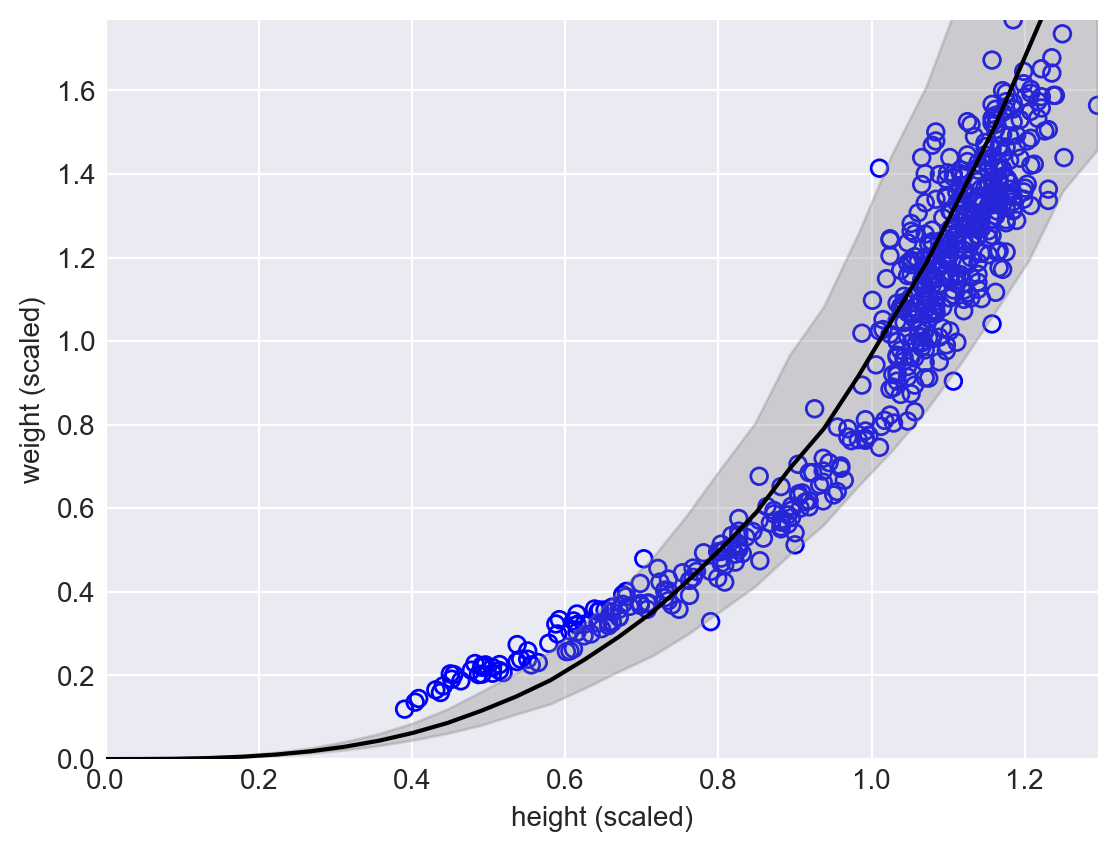

In [ ]:
post = trace_m16_1.posterior.stack(sample=("chain", "draw"))
h_seq = np.linspace(0, d.h.max(),30)
mu_sim = np.log(np.pi * post.k.values[None,:] * post.p.values[None,:] ** 2 * h_seq[:,None] ** 3)

w_sim = np.exp(mu_sim + np.random.normal(0, post.sigma.values[None,:], size=mu_sim.shape))
mu_mean = w_sim.mean(axis = 1)
w_CI = np.percentile(w_sim, [5.5, 94.5], axis=1)  
plt.scatter(d.h, d.w, facecolor = 'none', edgecolor ='blue')
plt.xlim(0,d.h.max())
plt.ylim(0,d.w.max())
plt.xlabel('height (scaled)')
plt.ylabel('weight (scaled)')
plt.plot(h_seq, mu_mean, color = 'black')
plt.fill_between(h_seq, w_CI[0], w_CI[1], color='grey', alpha = .3)


#### Code 16.4

In [76]:
boxes = pd.read_csv('data/boxes.csv',sep=';')
boxes.describe().T

,count,mean,std,min,25%,50%,75%,max
y,629.0,2.120827,0.727986,1.0,2.0,2.0,3.0,3.0
gender,629.0,1.505564,0.500367,1.0,1.0,2.0,2.0,2.0
age,629.0,8.030207,2.497906,4.0,6.0,8.0,10.0,14.0
majority_first,629.0,0.484897,0.500170,0.0,0.0,0.0,1.0,1.0
culture,629.0,3.751987,1.960319,1.0,3.0,3.0,5.0,8.0


#### Code 16.5

In [78]:
boxes.y.value_counts(sort = False) / boxes.y.shape[0]

y
1    0.211447
3    0.332273
2    0.456280
Name: count, dtype: float64

#### Code 16.6

In [92]:
np.random.seed(30)
N = 30
y1 = np.random.choice([0,1,2], size = N//2, replace = True)
y2 = np.repeat(1, N//2)
y = np.random.permutation(np.concatenate([y1,y2]))
sum(y==1) /N

0.8666666666666667

#### Code 16.7

In [ ]:
Boxes = pd.read_csv('data/boxes.csv', sep=';')


with pm.Model() as m16_2:
    p = pm.Dirichlet("p", a=np.repeat(4, 5))

    phi = [None] * 5
    phi[0] = pm.math.switch(Boxes.y == 2, 1.0, 0.0)   # majority
    phi[1] = pm.math.switch(Boxes.y == 3, 1.0, 0.0)   # minority
    phi[2] = pm.math.switch(Boxes.y == 1, 1.0, 0.0)   # maverick
    phi[3] = pm.math.full(len(Boxes), 1.0 / 3.0)   
    phi[4] = pm.math.switch(
        Boxes.majority_first == 1,
        pm.math.switch(Boxes.y == 2, 1.0, 0.0),
        pm.math.switch(Boxes.y == 3, 1.0, 0.0),
    )

    for j in range(5):
        phi[j] = pm.math.log(p[j]) + np.log(phi[j])

    pm.Potential("logprob", pm.math.logsumexp(pm.math.stack(phi, axis=1), axis=1))

,y,gender,age,majority_first,culture
0,1,1,6,0,2
1,3,1,8,0,2
2,2,2,8,1,2
3,1,1,6,0,2
4,2,1,5,1,2
...,...,...,...,...,...
624,1,1,12,0,3
625,2,2,13,0,3
626,2,2,12,1,3
627,2,2,13,1,3


#### Code 16.8

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 13 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


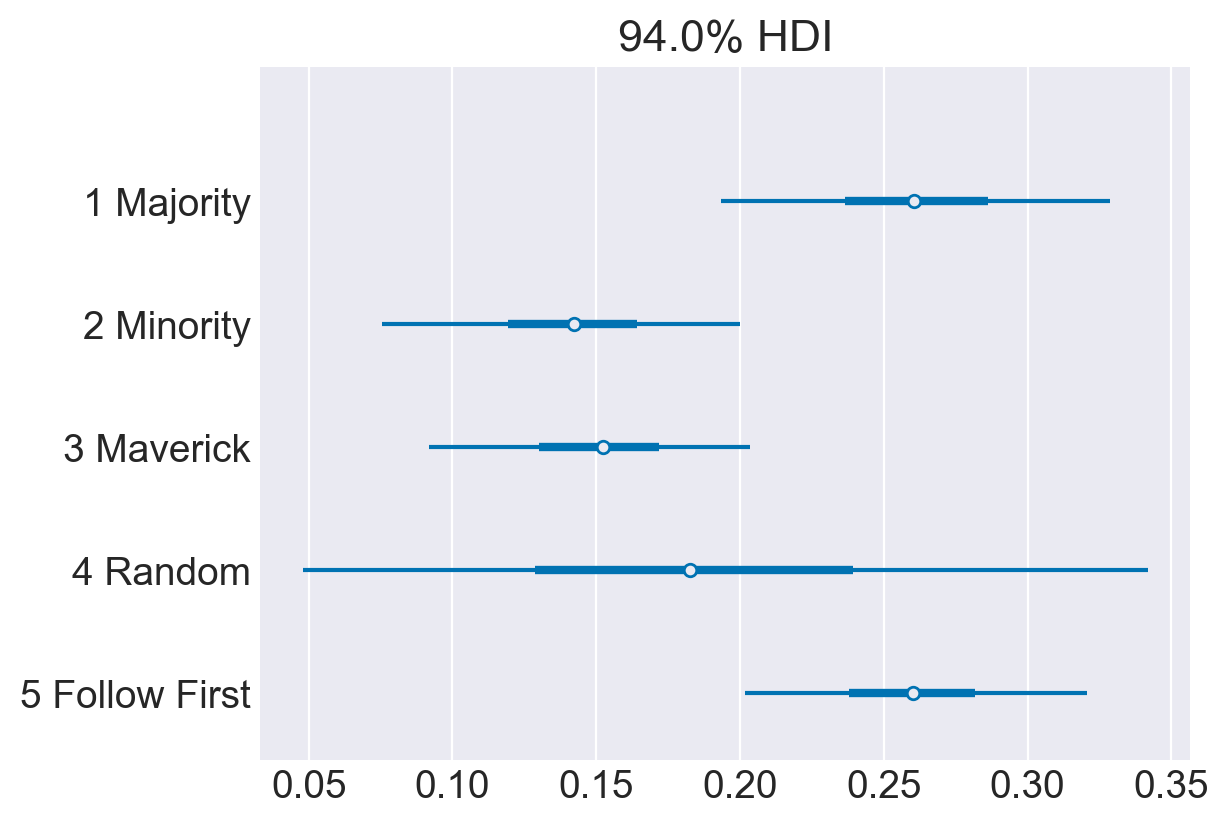

In [108]:
coords = ["5 Follow First", "4 Random", "3 Maverick", "2 Minority", "1 Majority"]


with m16_2:
    trace_m16_2 = pm.sample(cores=1)

az.plot_forest(trace_m16_2, combined= True)

plt.gca().set_yticklabels(coords);

#### Code 16.9

In [2]:
d = pd.read_csv('data/Panda_nuts.csv', sep=';')
d.head()

,chimpanzee,age,sex,hammer,nuts_opened,seconds,help
0,11,3,m,G,0,61.0,N
1,11,3,m,G,0,37.0,N
2,18,4,f,wood,0,20.0,N
3,18,4,f,G,0,14.0,y
4,18,4,f,L,0,13.0,N


#### Code 16.10

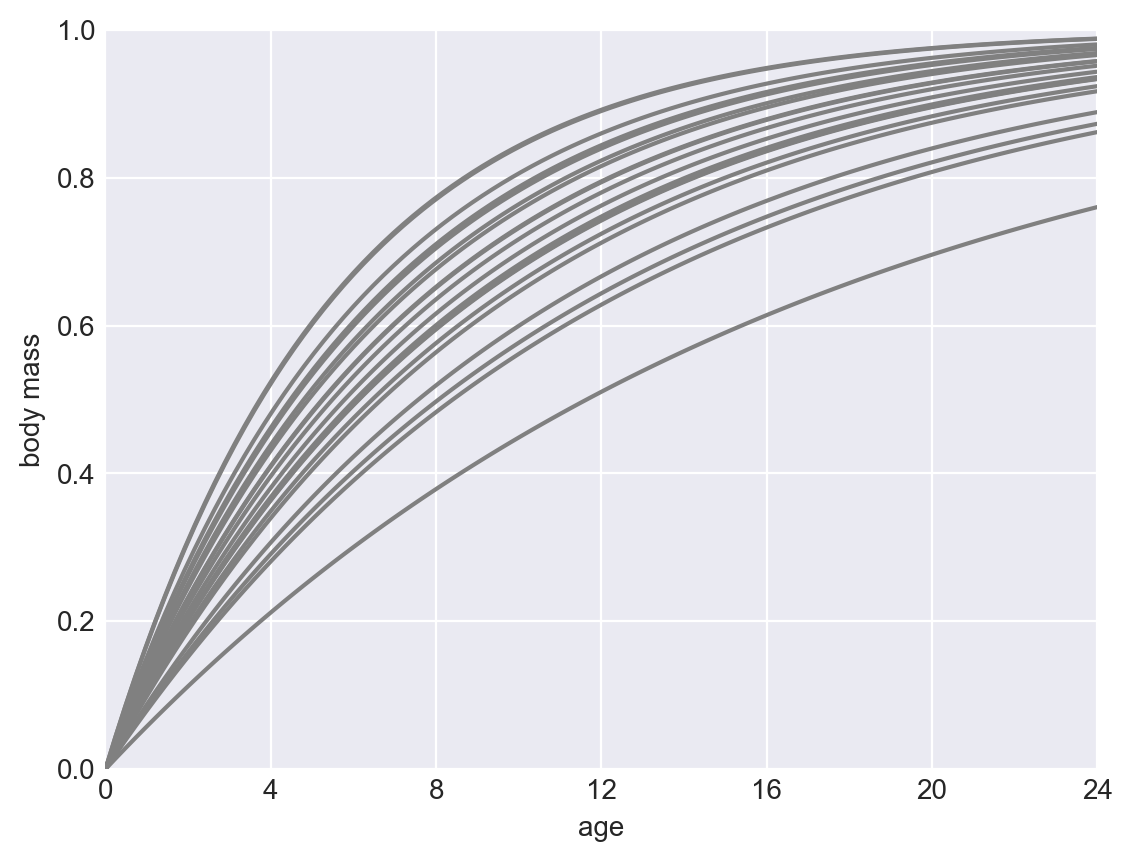

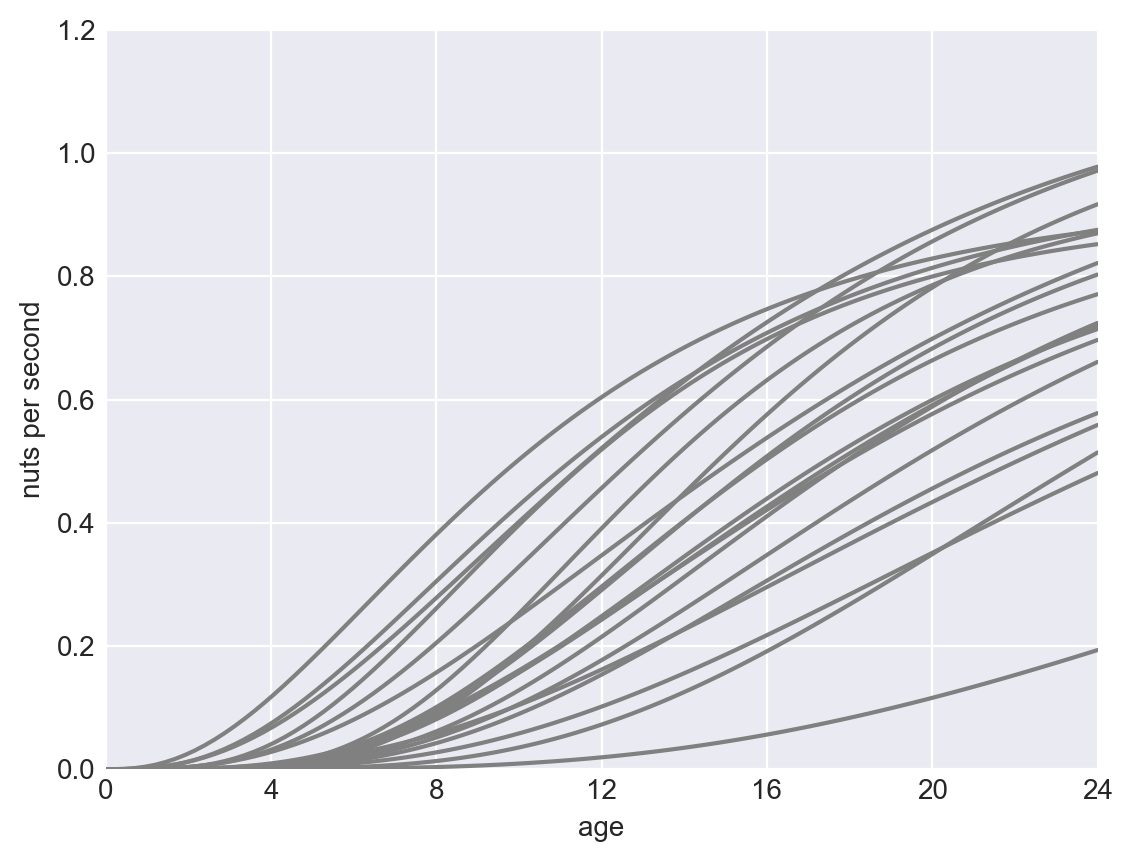

In [3]:
N = int(1e4)
phi = np.random.lognormal(np.log(1), .1, N)
k = np.random.lognormal(np.log(2), .25, N)
theta = np.random.lognormal(np.log(5), .25, N)

plt.figure()
plt.xlim(0,1.5)
plt.ylim(0,1)
plt.xlabel('age')
plt.ylabel('body mass')
at = [0,.25,.5,.75,1,1.25,1.5]
plt.xticks(at, labels=np.round(np.array(at) * d.age.max()).astype(int))

x = np.linspace(0, 1.5, 101)
for i in range(20):
    plt.plot(x, 1 - np.exp(-k[i] * x), "gray", lw=1.5)
plt.show()

plt.figure()
plt.xlim(0,1.5)
plt.ylim(0,1.2)
plt.xlabel('age')
plt.ylabel('nuts per second')
at = [0,.25,.5,.75,1,1.25,1.5]
plt.xticks(at, labels=np.round(np.array(at) * d.age.max()).astype(int))

x = np.linspace(0, 1.5, 101)
for i in range(20):
    plt.plot(x, phi[i] * (1 - np.exp(-k[i] * x))**theta[i], "gray", lw=1.5)
plt.show()

#### Code 16.11

In [5]:
dat_list = pd.DataFrame({
    'N': d.nuts_opened,
    'age': d.age / d.age.max(),
    'seconds': d.seconds
})

with pm.Model() as m16_4:
    theta = pm.LogNormal('theta', pm.math.log(5), .25)
    k = pm.LogNormal('k', pm.math.log(2), .25)
    phi = pm.LogNormal('phi', pm.math.log(1), .1)
    lambda_ = pm.Deterministic('lambda', dat_list.seconds.values * phi * (1 - pm.math.exp(-k * dat_list.age.values)) ** theta)
    n = pm.Poisson('n', lambda_, observed = dat_list.N)
    trace_m16_4 = pm.sample(cores = 1)


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [theta, k, phi]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


#### Code 6.12

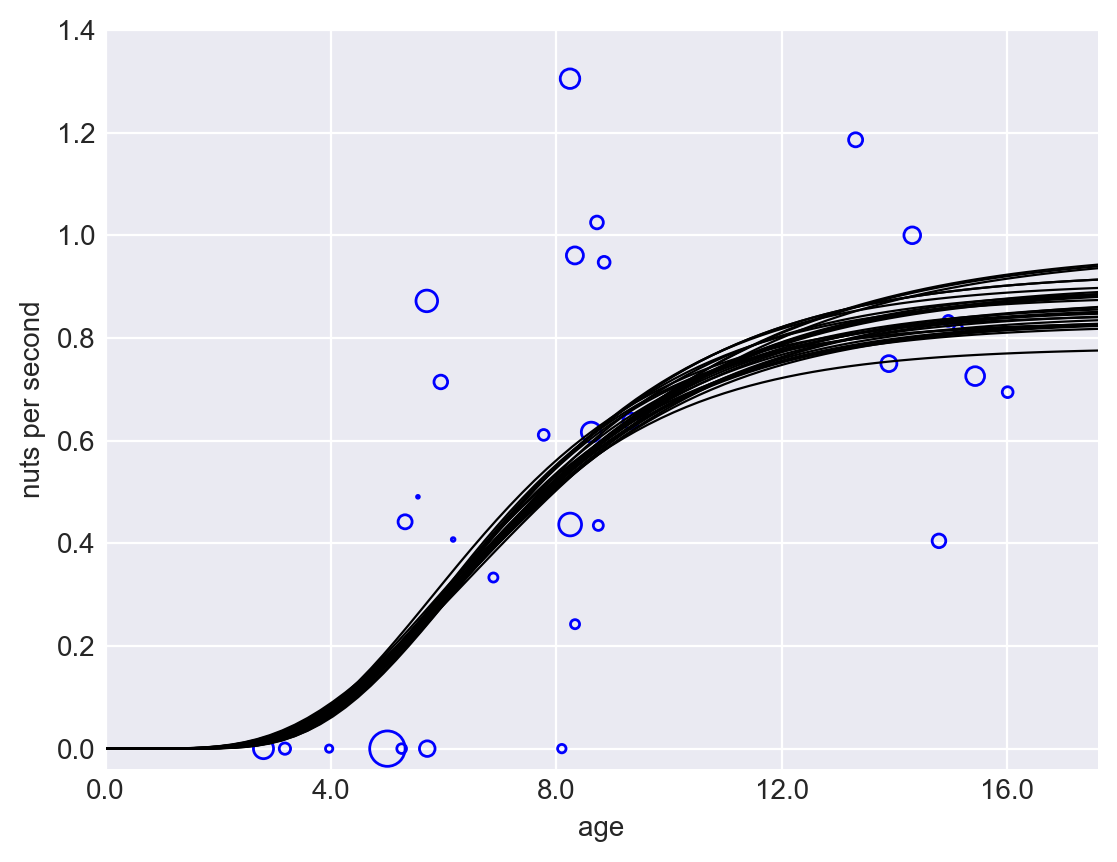

In [6]:
post = trace_m16_4.posterior.stack(sample=("chain", "draw"))

plt.figure()
plt.xlim(0,1.1)
plt.ylim(-.04,1.4)
plt.xlabel('age')
plt.ylabel('nuts per second')

at = [0,.25,.5,.75,1]
plt.xticks(at, labels=np.round(np.array(at) * 16))

pts = dat_list.N / dat_list.seconds
point_size = scaler.fit_transform(dat_list[['seconds']])
plt.scatter(dat_list.age + np.random.normal(0, 0.02, size=len(dat_list.age)), 
            pts, facecolor = 'none', edgecolor='blue', s = point_size.flatten() * 30)

x = np.linspace(0, 1.4, 101)
for i in range(30):
    plt.plot(x, post.phi.values[i] * (1 - np.exp(-post.k.values[i] * x)) ** post.theta.values[i], color = "black", lw = .8)


#### Code 16.13

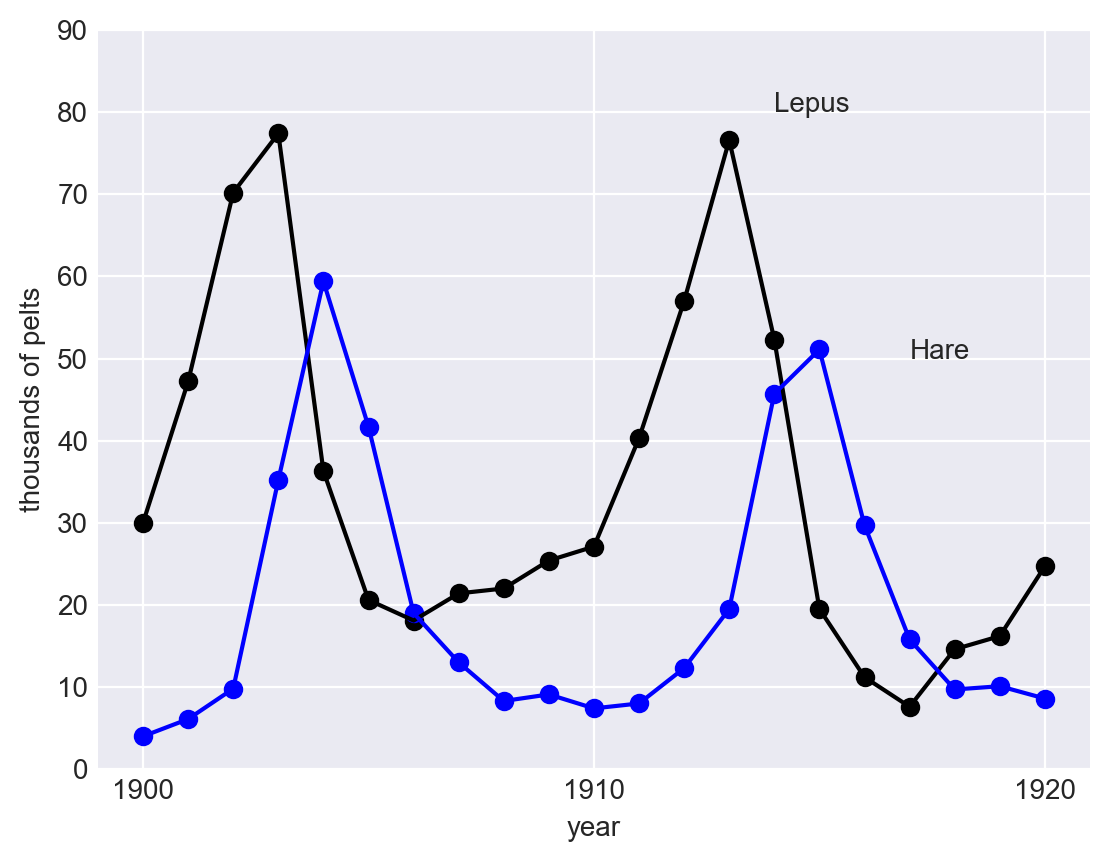

In [7]:
Lynx_hare = pd.read_csv('data/Lynx_Hare.csv',sep=';')
plt.plot(range(21), Lynx_hare.Hare, color = 'black')
plt.ylim(0,90)
plt.xlabel('year')
plt.ylabel('thousands of pelts')
at = [0,10,20]
plt.xticks(at, labels=Lynx_hare.Year.iloc[at])
plt.plot(range(21), Lynx_hare.Lynx, color = 'blue')
plt.scatter(range(21), Lynx_hare.Hare, color = 'black')
plt.scatter(range(21), Lynx_hare.Lynx, color = 'blue')
plt.text(14,80, "Lepus")
plt.text(17,50, "Hare");

#### Code 16.14

In [8]:
def sim_lynx_hare(n_steps, init, theta, dt=0.002):
    L = np.full(n_steps, np.nan)
    H = np.full(n_steps, np.nan)
    L[0] = init[0]
    H[0] = init[1]
    for i in range(1, n_steps):
        H[i] = H[i-1] + dt * H[i-1] * (theta[0] - theta[1] * L[i-1])
        L[i] = L[i-1] + dt * L[i-1] * (theta[2] * H[i-1] - theta[3])
    return np.column_stack([L, H])

#### Code 16.15

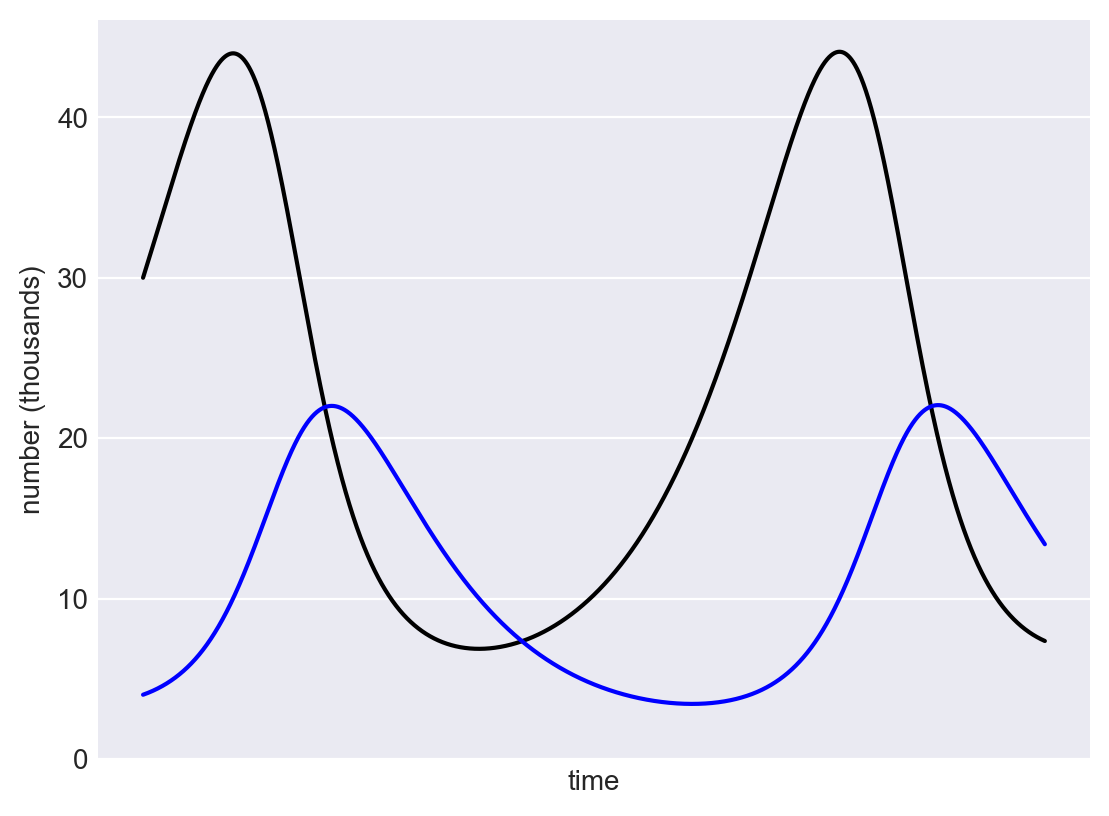

In [9]:
theta = [.5,.05, .025, .5]
z = sim_lynx_hare(10000, Lynx_hare.values[0,1:3], theta)

plt.plot(z[:,1], color = 'black')
plt.plot(z[:,0], color = 'blue')
plt.ylim(0, z[:,1].max() + 2)
plt.gca().set_xticks([])
plt.xlabel('time')
plt.ylabel('number (thousands)');

#### Code 16.16

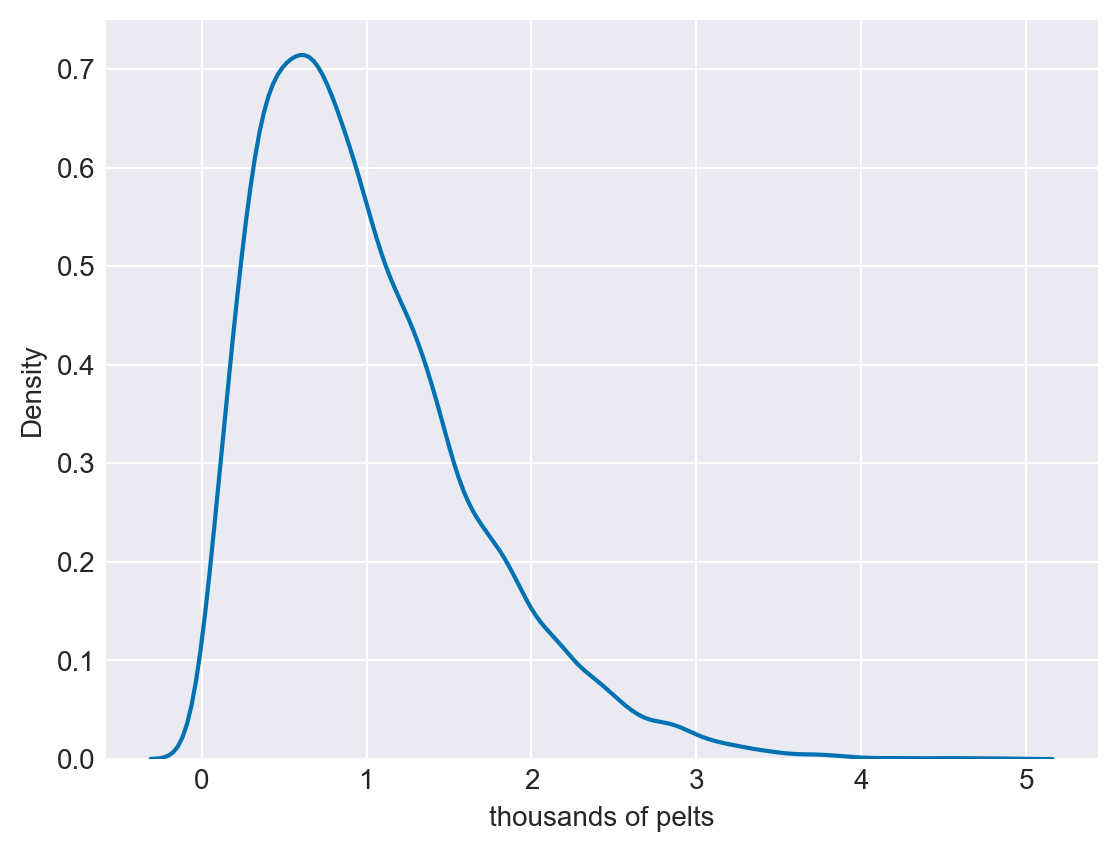

In [10]:
N = int(1e4)
Ht = int(1e4)
p = np.random.beta(2,18,N)
h = np.random.binomial(n = Ht, p = p, size = N)
h = np.round(h/1000, 2)
sns.kdeplot(h)
plt.xlabel('thousands of pelts');

#### Code 16.17

In [ ]:
import pytensor
import pytensor.tensor as pt

#This will sample VERY slowly.  Defining our own ODE is very very slow

def lynx_hare_model(dat_list):
    with pm.Model() as m16_5:
        theta = pm.TruncatedNormal("theta", mu=np.tile([1, 0.05], 2), sigma=np.tile([0.5, 0.05], 2), lower=0, shape=4)
        sigma = pm.Exponential("sigma", 1, shape=2)
        pop_init = pm.LogNormal("pop_init", mu=np.log(10), sigma=1, shape=2)
        p = pm.Beta("p", 40, 200, shape=2)

        dt = 0.01
        N = dat_list["N"]
        total_steps = (N - 1) * int(1 / dt)
        sample_every = int(1 / dt)

        def step(pop, theta):
            L, H = pop[0], pop[1]
            H_new = H + dt * H * (theta[0] - theta[1] * L)
            L_new = L + dt * L * (theta[3] * H - theta[2])
            H_new = pt.maximum(H_new, 1e-10)
            L_new = pt.maximum(L_new, 1e-10)
            return pt.stack([L_new, H_new])

        all_steps, _ = pytensor.scan(fn=step, outputs_info=pop_init, non_sequences=theta, n_steps=total_steps)

        yearly = all_steps[sample_every - 1::sample_every]
        pop = pm.Deterministic("pop", pt.concatenate([pop_init[None, :], yearly], axis=0))

        pm.LogNormal("pelts", mu=pm.math.log(pop * p), sigma=sigma, observed=dat_list["pelts"])

        trace = pm.sample(500, tune=50, chains=2, cores=1, target_accept=0.95,
                          initvals={"theta": np.array([0.5, 0.05, 0.05, 0.5]),
                                    "pop_init": np.array([10.0, 10.0])})

    return trace

#### code 16.18

In [30]:
dat_list = dict(
    N= Lynx_hare.shape[0],
    pelts = Lynx_hare.iloc[:, 1:3]
)

trace_m16_5 = lynx_hare_model(dat_list)

Only 50 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [theta, sigma, pop_init, p]


Output()

Sampling 2 chains for 50 tune and 50 draw iterations (100 + 100 draws total) took 809 seconds.
The number of samples is too small to check convergence reliably.


#### Code 16.19

Text(17, 50, 'Lynx')

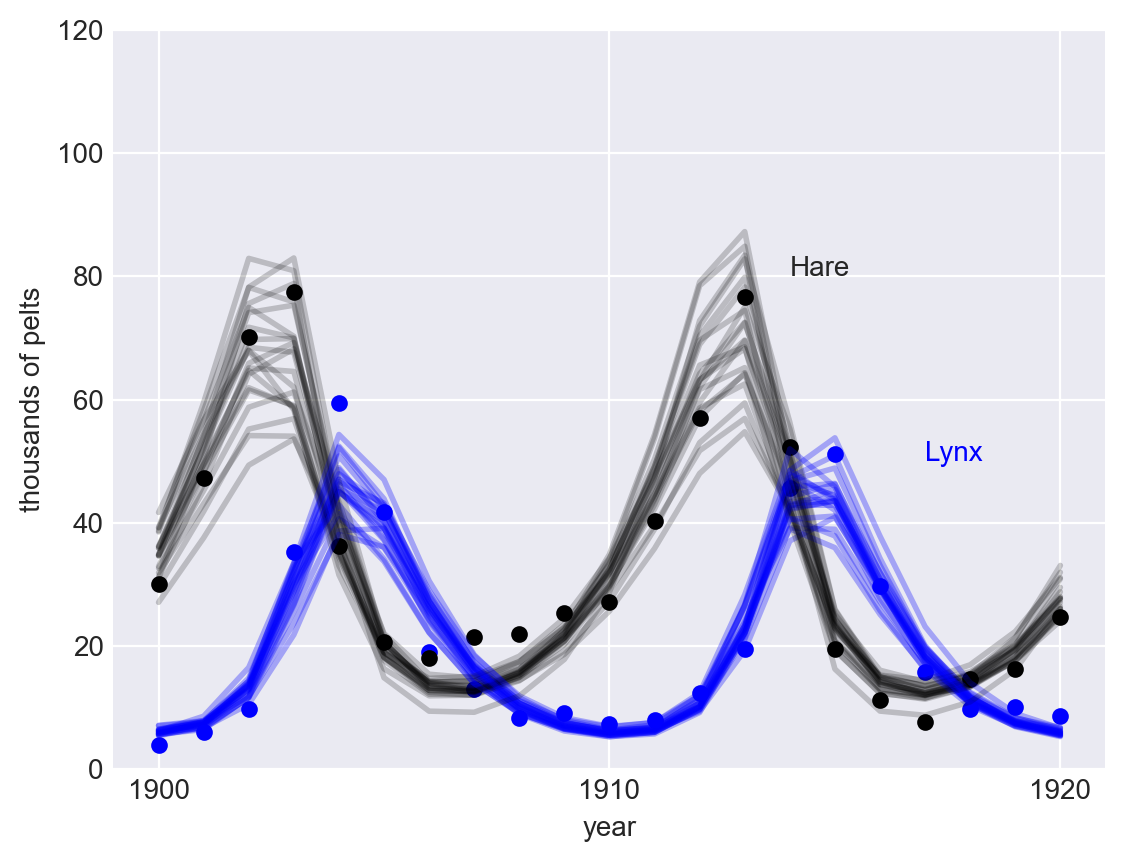

In [ ]:
post = trace_m16_5.posterior.stack(samples=("chain", "draw"))
pop = post["pop"].values          
p_vals = post["p"].values        
pelts_pred = pop * p_vals[None, :, :]  
pelts = dat_list["pelts"]

plt.figure()
plt.plot(range(21), pelts.iloc[:, 0], "b.", ms=10)
plt.plot(range(21), pelts.iloc[:, 1], "k.", ms=10)
plt.ylim(0, 120)
plt.xlabel("year")
plt.ylabel("thousands of pelts")
at = [0, 10, 20]
plt.xticks(at, labels=Lynx_hare.Year.iloc[at])

for s in range(21):
    plt.plot(range(21), pelts_pred[:, 1, s], "k", alpha=0.2, lw=2)
    plt.plot(range(21), pelts_pred[:, 0, s], color="blue", alpha=0.3, lw=2)
plt.text(14, 80, "Hare")
plt.text(17, 50, "Lynx", color="blue")

#### Code 16.20

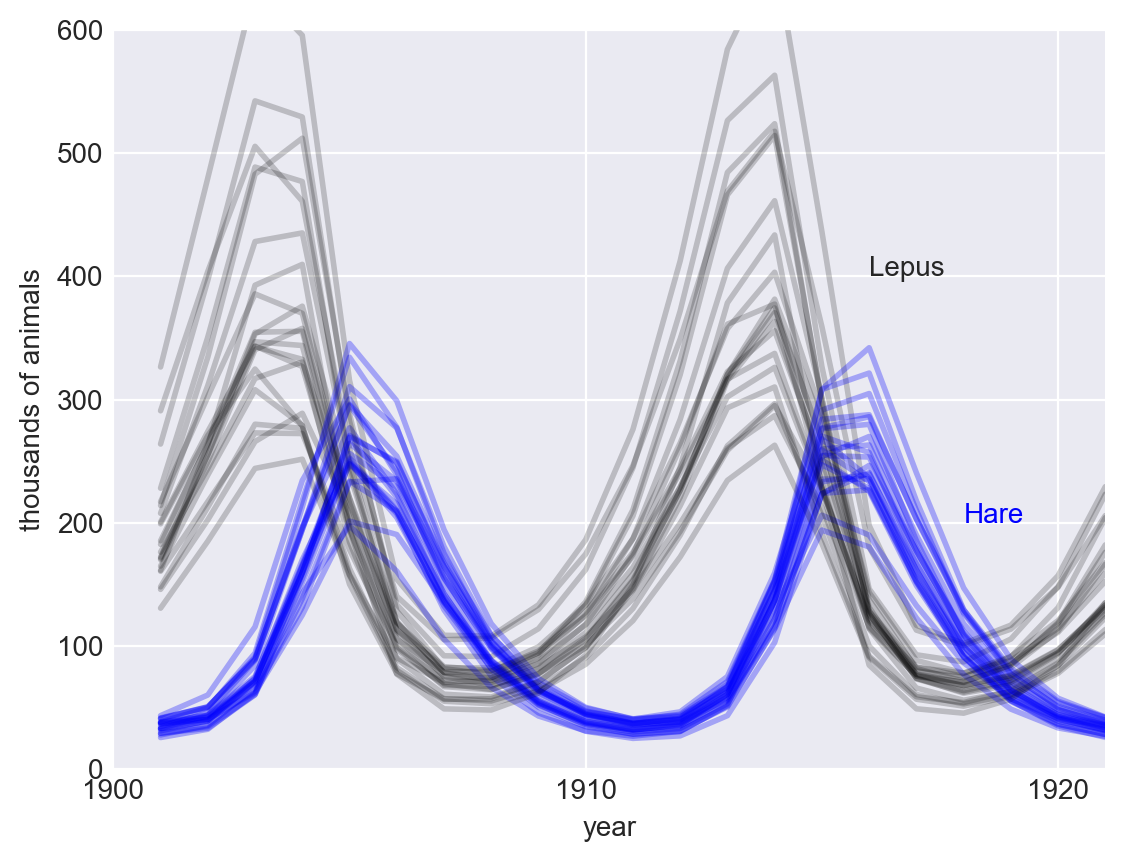

In [ ]:
plt.figure()
plt.xlim(1,21)
plt.ylim(0,600)
plt.xlabel('year')
plt.ylabel('thousands of animals')
at = [0,10,20]
plt.xticks(at, labels=Lynx_hare.Year.iloc[at])
for s in range(21):
    plt.plot(range(1, 22), post["pop"][:,1,s], "k", alpha=0.2, lw=2)
    plt.plot(range(1, 22), post["pop"][:,0,s], "b", alpha=0.3, lw=2)
plt.text(16,400, "Lepus")
plt.text(18,200, "Hare", color = 'blue');